In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("../dataset/data.xlsx")

# Show first 5 rows
display(df.head())

# Dataset information
print(df.info())

# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("Columns:")
print(df.columns)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [51]:
# Check missing values
print("MISSING VALUES:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDUPLICATE RECORDS:")
print(df.duplicated().sum())

# Statistical summary
print("\nSTATISTICAL SUMMARY:")
display(df.describe())

# Data types
print("\nDATA TYPES:")
print(df.dtypes)

MISSING VALUES:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

DUPLICATE RECORDS:
0

STATISTICAL SUMMARY:


,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558



DATA TYPES:
OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object


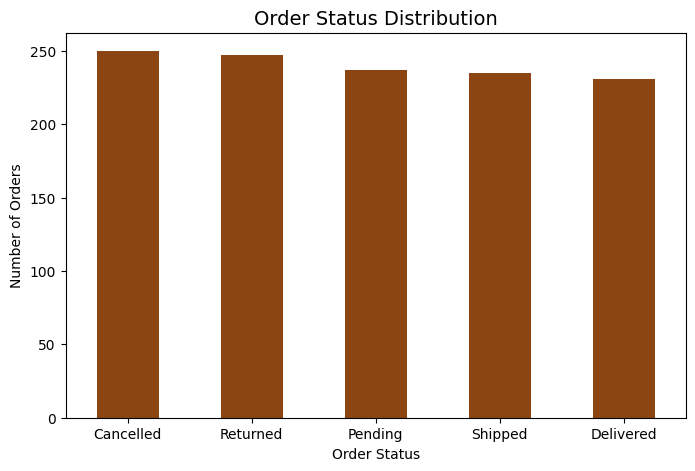

In [52]:
# Order Status Count Chart

order_status = df['OrderStatus'].value_counts()

plt.figure(figsize=(8,5))

order_status.plot(
    kind='bar',
    color='saddlebrown'
)

plt.title("Order Status Distribution", fontsize=14)

plt.xlabel("Order Status")

plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.show()

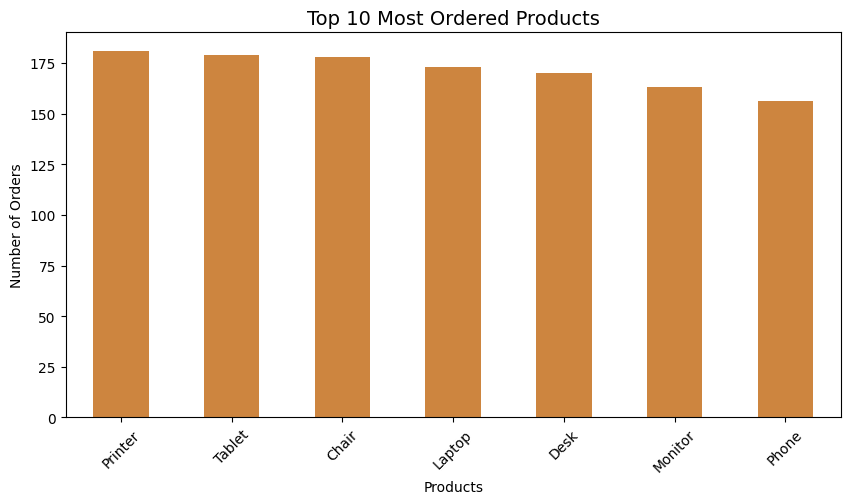

In [53]:
# Top Products Chart

top_products = df['Product'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_products.plot(
    kind='bar',
    color='peru'
)

plt.title("Top 10 Most Ordered Products", fontsize=14)

plt.xlabel("Products")

plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

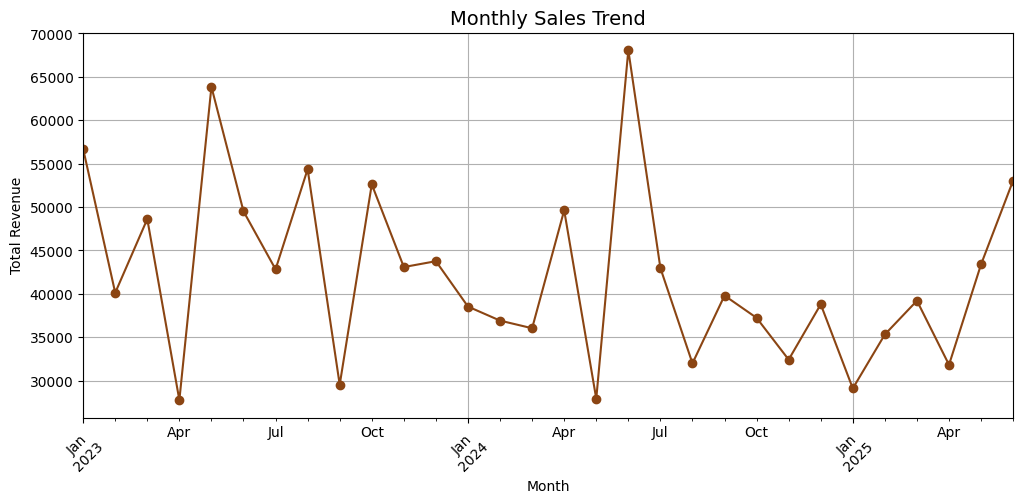

In [54]:
# Monthly Sales Trend

df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot(
    kind='line',
    marker='o',
    color='saddlebrown'
)

plt.title("Monthly Sales Trend", fontsize=14)

plt.xlabel("Month")

plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

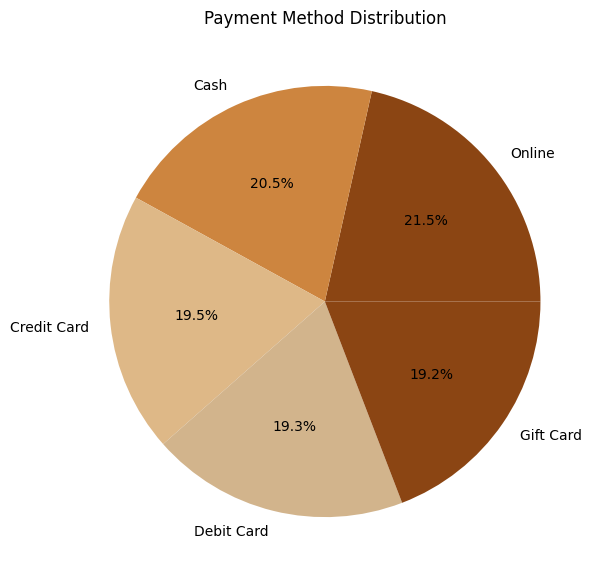

In [55]:
# Payment Method Distribution

payment_method = df['PaymentMethod'].value_counts()

plt.figure(figsize=(7,7))

payment_method.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['saddlebrown','peru','burlywood','tan']
)

plt.title("Payment Method Distribution")

plt.ylabel("")

plt.show()

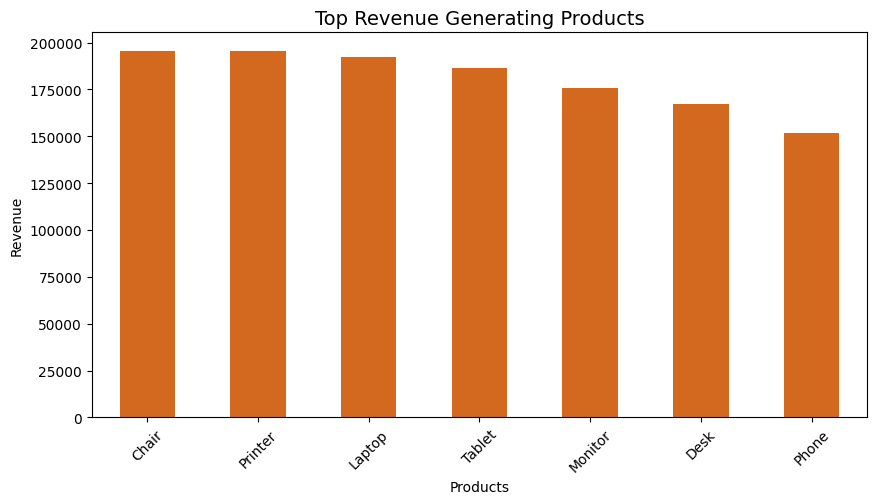

In [56]:
# Revenue by Product

product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

product_revenue.plot(
    kind='bar',
    color='chocolate'
)

plt.title("Top Revenue Generating Products", fontsize=14)

plt.xlabel("Products")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

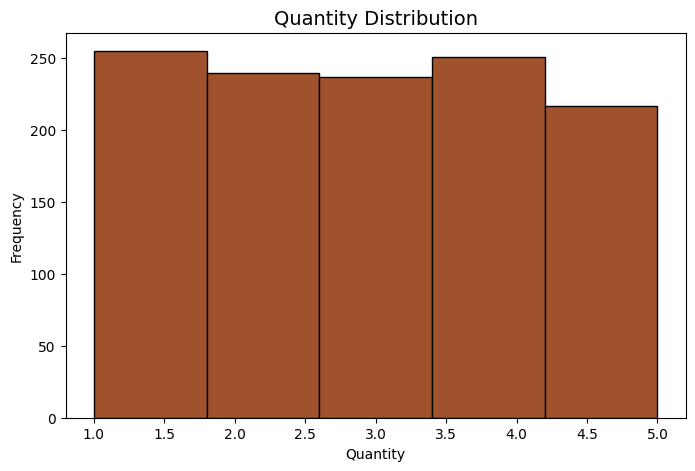

In [57]:
# Quantity Distribution

plt.figure(figsize=(8,5))

plt.hist(
    df['Quantity'],
    bins=5,
    color='sienna',
    edgecolor='black'
)

plt.title("Quantity Distribution", fontsize=14)

plt.xlabel("Quantity")

plt.ylabel("Frequency")

plt.show()

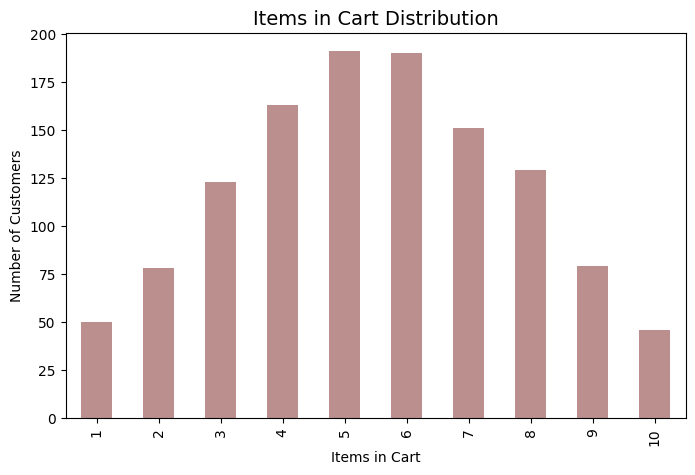

In [58]:
# Items In Cart Analysis

plt.figure(figsize=(8,5))

df['ItemsInCart'].value_counts().sort_index().plot(
    kind='bar',
    color='rosybrown'
)

plt.title("Items in Cart Distribution", fontsize=14)

plt.xlabel("Items in Cart")

plt.ylabel("Number of Customers")

plt.show()

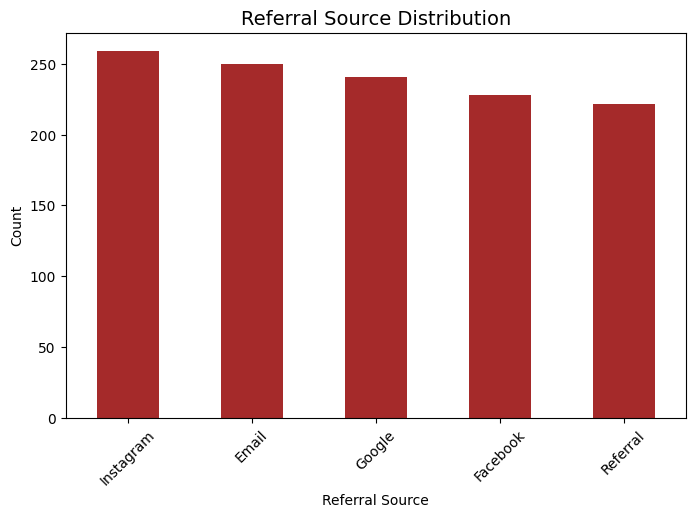

In [59]:
# Referral Source Analysis

referral = df['ReferralSource'].value_counts()

plt.figure(figsize=(8,5))

referral.plot(
    kind='bar',
    color='brown'
)

plt.title("Referral Source Distribution", fontsize=14)

plt.xlabel("Referral Source")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()